In [69]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

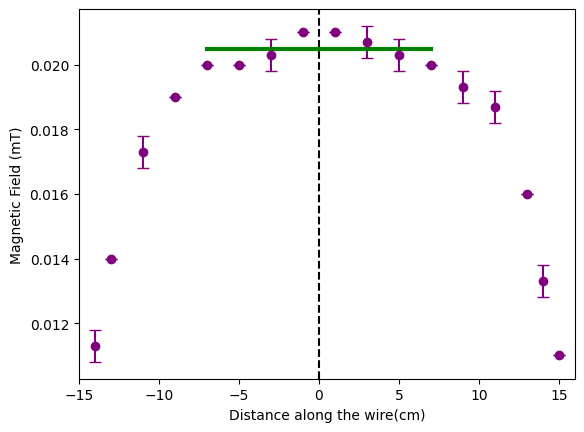

In [61]:
#Experiment 1 - A

x = np.array([-14, -13, -11, -9, -7, -5, -3, -1, 1, 3, 5, 7, 9, 11, 13, 14, 15])


data = [0.0113, 0.014, 0.0173, 0.019, 0.020, 0.020, 0.0203, 0.021, 0.021, 0.0207, 0.0203, 0.02, 0.0193, 0.0187, 0.016, 0.0133, 0.011]
stdev = [0.0005, 0, 0.0005, 0, 0, 0, 0.0005, 0, 0, 0.0005, 0.0005, 0, 0.0005, 0.0005, 0, 0.0005, 0]



fig, ax = plt.subplots()

ax.errorbar(x, data, yerr=stdev,
            fmt="o", color="purple", capsize=4,
           )
ax.set_xlim(-15, 16)
ax.axvline(0, color = "black", linestyle='--')  # vertical center line
ax.plot([-7, 7], [0.0205, 0.0205], color='green', linewidth=3)
ax.set_xlabel("Distance along the wire(cm)")
ax.set_ylabel("Magnetic Field (mT)")

plt.show()

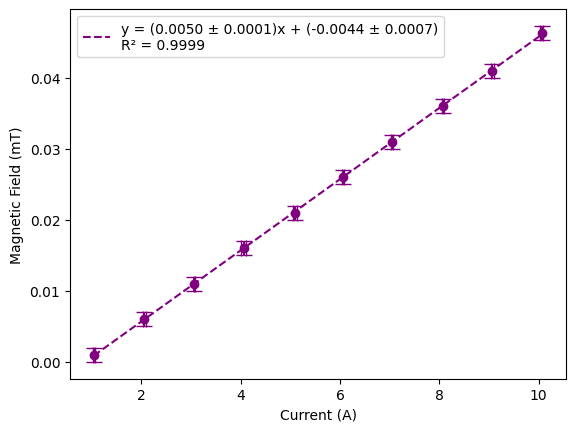

μ₀ from slope: 9.4500e-04 ± 2.0741e-05


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Data
x = np.array([1.043, 2.063, 3.067, 4.067, 5.093, 6.057, 7.050, 8.067, 9.067, 10.06])
x_stdev = np.array([0.021, 0.029, 0.012, 0.049, 0.038, 0.017, 0.014, 0.019, 0.031, 0.036])

data = np.array([0.001, 0.006, 0.011, 0.016, 0.021, 0.026, 0.031, 0.036, 0.041, 0.0463])

# FIX: use instrument uncertainty
data_stdev = np.full_like(data, 0.001)

def lin(x, a, b):
    return a*x + b

def r_squared(y, yf):
    ss_res = np.sum((y - yf) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - ss_res / ss_tot

# FIX: include sigma
po1, pc1 = curve_fit(
    lin, x, data,
    sigma=data_stdev,
    absolute_sigma=True,
    p0=[1, 0.002]
)

a, b = po1
perr = np.sqrt(np.diag(pc1))
a_err, b_err = perr

# Plot
fig, ax = plt.subplots()

ax.plot(
    x,
    lin(x, *po1),
    linestyle="dashed",
    color="purple",
    label=f"y = ({a:.4f} ± {a_err:.4f})x + ({b:.4f} ± {b_err:.4f})\nR² = {r_squared(data, lin(x, *po1)):.4f}"
)

ax.errorbar(
    x, data,
    xerr=x_stdev,
    yerr=data_stdev,
    fmt="o",
    color="purple",
    capsize=6
)

ax.set_xlabel("Current (A)")
ax.set_ylabel("Magnetic Field (mT)")
ax.legend()

plt.show()

# μ₀ calculation
r = 0.03  # m
mu0_from_slope = a * 2 * np.pi * r
mu0_err_from_slope = a_err * 2 * np.pi * r

print(f"μ₀ from slope: {mu0_from_slope:.4e} ± {mu0_err_from_slope:.4e}")

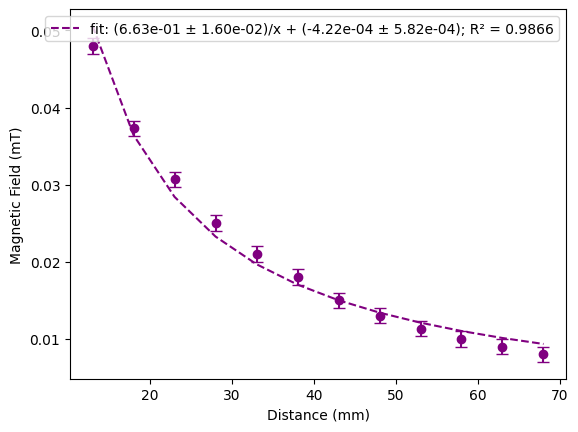

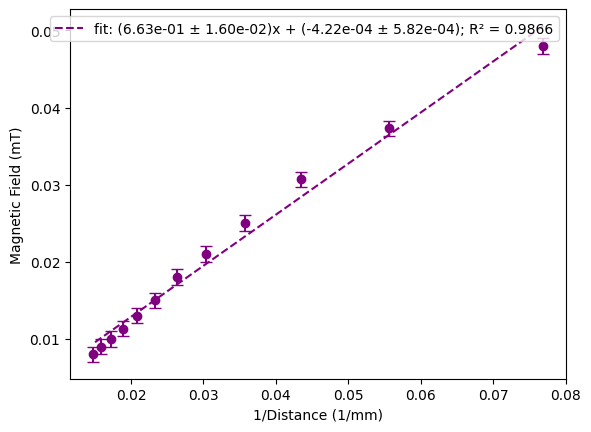

μ₀ from slope: 8.3497e-04 ± 2.0157e-05 T·m/A


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# -----------------------------
# Raw data (KEEP IN mT and mm)
# -----------------------------
r_mm = np.array([13, 18, 23, 28, 33, 38, 43, 48, 53, 58, 63, 68])  # mm
B_mT = np.array([0.048, 0.0373, 0.0307, 0.025, 0.021, 0.018,
                 0.015, 0.013, 0.0113, 0.01, 0.009, 0.008])  # mT

# uncertainty (mT)
stdev_B_mT = np.full_like(B_mT, 0.001)

# -----------------------------
# Models
# -----------------------------
def lin(x, a, b):
    return a * x + b

def inv(x, c, d):
    return c / x + d

def r_squared(y, yf):
    ss_res = np.sum((y - yf) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - (ss_res / ss_tot)

# =============================
# FIT 1: inverse fit (B vs r)
# =============================
po1, pc1 = curve_fit(
    inv,
    r_mm,
    B_mT,
    sigma=stdev_B_mT,
    absolute_sigma=True,
    p0=[1, 0]
)

c, d = po1
c_err, d_err = np.sqrt(np.diag(pc1))

fig, ax = plt.subplots()

ax.errorbar(
    r_mm,
    B_mT,
    yerr=stdev_B_mT,
    fmt="o",
    color="purple",
    capsize=4
)

ax.plot(
    r_mm,
    inv(r_mm, *po1),
    linestyle="dashed",
    color="purple",
    label=f"fit: ({c:.2e} ± {c_err:.2e})/x + ({d:.2e} ± {d_err:.2e}); "
          f"R² = {np.round(r_squared(B_mT, inv(r_mm, *po1)), 4)}"
)

ax.set_xlabel("Distance (mm)")
ax.set_ylabel("Magnetic Field (mT)")
ax.legend()

plt.show()

# =============================
# FIT 2: linearized fit
# B = a*(1/r) + b
# x-axis in 1/mm
# =============================
r_inv = 1 / r_mm  # 1/mm

po2, pc2 = curve_fit(
    lin,
    r_inv,
    B_mT,
    sigma=stdev_B_mT,
    absolute_sigma=True
)

a, b = po2
a_err, b_err = np.sqrt(np.diag(pc2))

fig, ax = plt.subplots()

ax.errorbar(
    r_inv,
    B_mT,
    yerr=stdev_B_mT,
    fmt="o",
    color="purple",
    capsize=4
)

ax.plot(
    r_inv,
    lin(r_inv, *po2),
    linestyle="dashed",
    color="purple",
    label=f"fit: ({a:.2e} ± {a_err:.2e})x + ({b:.2e} ± {b_err:.2e}); "
          f"R² = {np.round(r_squared(B_mT, lin(r_inv, *po2)), 4)}"
)

ax.set_xlabel("1/Distance (1/mm)")
ax.set_ylabel("Magnetic Field (mT)")
ax.legend()

plt.show()

# =============================
# μ₀ calculation
# =============================
I = 4.99  # A

# a has units: mT * mm
# convert:
# 1 mT = 1e-3 T
# 1 mm = 1e-3 m
# so slope in SI (T·m) = a * 1e-6
mu0_from_slope = 2 * np.pi * a * 1e-3 / I
mu0_err_from_slope = 2 * np.pi * a_err * 1e-3 / I

print(f"μ₀ from slope: {mu0_from_slope:.4e} ± {mu0_err_from_slope:.4e} T·m/A")

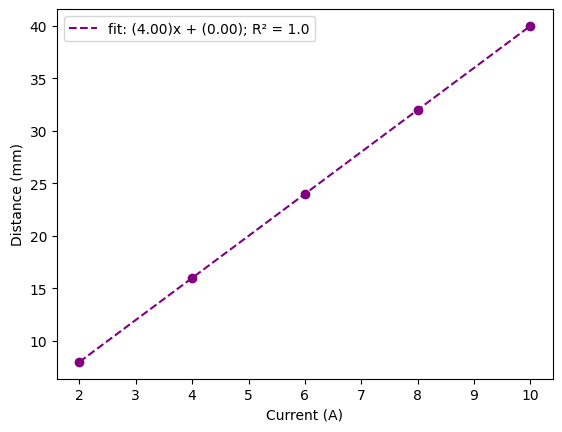

In [75]:
#Preparatory question 3

I = np.array([2,4,6,8,10])
r = np.array([8,16,24,32,40])

def lin (x,a,b):
    return a*x+b

def r_squared(y,yf):
    y_data = np.array(y)
    y_fit = np.array(yf)
    ss_res = np.sum((y_data - y_fit) ** 2)              
    ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)   
    return 1 - (ss_res / ss_tot)

po2, pc2 = curve_fit(lin, I, r, p0=[1,0.002], bounds=(0, np.inf))



c, d = po2

fig, ax = plt.subplots()
ax.plot(I, r, "o", color="purple")
ax.plot(I,
        lin(I, *po2),
        linestyle="dashed",
        color="purple",
        label=f"fit: ({c:.2f})x + ({d:.2f}); R² = {np.round(r_squared(r, lin(I, *po2)),4)}")
ax.legend()
ax.set_xlabel("Current (A)")
ax.set_ylabel("Distance (mm)")


plt.show()


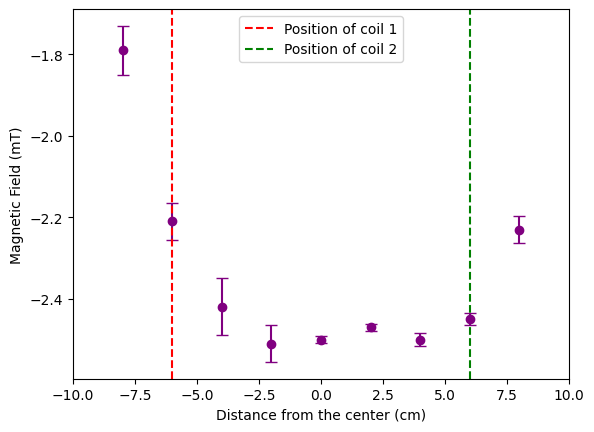

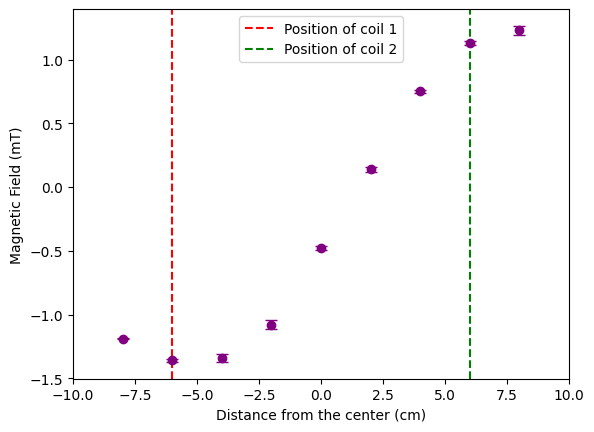

In [72]:
#Experiment 3 D & E

x = np.array([8, 6, 4, 2, 0, -2, -4, -6, -8])


data_p = [-2.23, -2.45, -2.5, -2.47, -2.5, -2.51, -2.42, -2.21, -1.79]
stdev_p = [0.033, 0.014, 0.016, 0.009, 0.008, 0.045, 0.070, 0.045, 0.060]
data_ap = [1.23, 1.13, 0.75, 0.14, -0.48, -1.08, -1.34, -1.36, -1.19]
stdev_ap = [0.034, 0.012, 0.012, 0.019, 0.017, 0.037, 0.029, 0.012, 0.004]

fig, ax = plt.subplots()

ax.errorbar(x, data_p, yerr=stdev_p,
            fmt="o", color="purple", capsize=4,
           )
ax.set_xlim(-10, 10)
ax.axvline(-6, color = "red", linestyle='--', label="Position of coil 1")
ax.axvline(6, color = "green", linestyle='--', label="Position of coil 2")
ax.set_xlabel("Distance from the center (cm)")
ax.set_ylabel("Magnetic Field (mT)")
ax.legend()

plt.show()

fig, ax = plt.subplots()

ax.errorbar(x, data_ap, yerr=stdev_ap,
            fmt="o", color="purple", capsize=4,
           )
ax.set_xlim(-10, 10)
ax.axvline(-6, color = "red", linestyle='--', label="Position of coil 1")
ax.axvline(6, color = "green", linestyle='--', label="Position of coil 2")
ax.set_xlabel("Distance from the center (cm)")
ax.set_ylabel("Magnetic Field (mT)")
ax.legend()

plt.show()